### Algorithm from Scratch

In [13]:
import torch
import torch.nn as nn


In [14]:
# class for the backbone
from torchvision import models
class Backbone(nn.Module):
    def __init__(self, d_model: int = 256):
        super().__init__()
        resnet = models.resnet50(weights = models.ResNet50_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        # print(self.backbone.children)
        self.projection = nn.Conv2d(2048,d_model,1)


    def forward(self,x):
        x = self.backbone(x)
        x = self.projection(x)
        # print(x.shape)
        return x

test = torch.randn((2,3,800,800))
test = Backbone()(test)
print(test.shape)

KeyboardInterrupt: 

In [ ]:
import math
import matplotlib.pyplot as plt

class PositionalEncoding2D(nn.Module):
    def __init__(self,d_model: int = 256,
                 temperature: int = 10000):
        super().__init__()
        assert d_model % 2 == 0, "Provide the Even dimension as positional Dimension"
        self.d_model = d_model
        self.d_half = d_model // 2
        self.temperature = temperature


        i = torch.arange(self.d_half//2 , dtype=torch.float32)
        freq = self.temperature**(2*i / self.d_half)

        self.register_buffer('freq',freq)
        
    def _compute_1d_pe(self, positions: torch.Tensor) -> torch.Tensor:
        angles = positions[:, None] / self.freq[None,:]

        pe = torch.zeros(len(positions), self.d_half,
                         device= positions.device, dtype= torch.float32)
        
        pe[:, 0::2] = torch.sin(angles)
        pe[:, 1::2] = torch.cos(angles)

        return pe


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Returning only PE, combining it latter in different class iwth actuall tensor"""
        b, c, h, w = x.shape

        y_position = torch.arange(h, device=x.device, dtype=torch.float32)
        x_position = torch.arange(w, device=x.device, dtype=torch.float32)

        y_pe = self._compute_1d_pe(y_position)
        x_pe = self._compute_1d_pe(x_position)

        y_broadcast = y_pe[:, None, :].expand(h,w,self.d_half)
        x_broadcast = x_pe[None, :, :].expand(h,w,self.d_half)

        pe = torch.cat([y_broadcast,x_broadcast], dim = -1)
        pe = pe.permute(2,0,1).unsqueeze(0)

        return pe#x + pe


In [ ]:
pe_module = PositionalEncoding2D(d_model=256)
dummy     = torch.zeros(1, 256, 15, 15)
output    = pe_module(dummy)    # (1, 256, 15, 15)

# Extract the PE (since input was zeros, output IS the PE)
pe = output[0]    # (256, 15, 15)

# Test 1: two different rows at same column should be different
assert not torch.allclose(pe[:, 0, 0], pe[:, 1, 0]), \
    "Row 0 and Row 1 should have different encodings"

# Test 2: two different cols at same row should be different  
assert not torch.allclose(pe[:, 0, 0], pe[:, 0, 1]), \
    "Col 0 and Col 1 should have different encodings"

# Test 3: same position across batch should be identical
dummy2   = torch.zeros(4, 256, 15, 15)
output2  = pe_module(dummy2)
assert torch.allclose(output2[0], output2[1]), \
    "Same position should get same PE regardless of batch index"

print("All assertions passed — PE is working correctly")

IndexError: index 1 is out of bounds for dimension 0 with size 1

### Encoder building

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self,embedding_dim :int= 256,
                 num_heads : int = 8,
                 dropout : float = 0.1,
                #  device : str = None,
                 ffn_dim : int = 2048
                         ):
        super().__init__()
        self.mhsa = nn.MultiheadAttention(embed_dim=embedding_dim,
                                          num_heads=num_heads,
                                          dropout=dropout,
                                        #   device=device,
                                          batch_first=False)
        self.norm1 = nn.LayerNorm(normalized_shape= embedding_dim)
        self.norm2 = nn.LayerNorm(normalized_shape=embedding_dim)
        self.feedforward = nn.Linear(embedding_dim, ffn_dim)
        self.feedforward2 = nn.Linear(ffn_dim, embedding_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, pe, src_key_padding_mask = None):
        # shape : (seq, batch, dim)
        q = x + pe 
        k = x + pe
        v = x

        attention_output, _ = self.mhsa(q, k, v,
                                        need_weights = False,
                                        key_padding_mask = src_key_padding_mask) # to include key padding mask here for the q,k,v

        norm_output = self.norm1(x + self.dropout(attention_output))
        ffn_output = self.feedforward2(self.dropout(self.relu(self.feedforward(norm_output))))
        return self.norm2( self.dropout(ffn_output) + norm_output)



In [ ]:
class Encoder(nn.Module):
    def __init__(self,
                 heads:int = 8,
                 dff : int = 2048,
                 dropout : float = 0.1,
                 embedding_dim : int = 256,
                 num_encoders : int = 6
                 ):
        super().__init__()
        # self.encoder_layer = EncoderLayer(embedding_dim=embedding_dim,
        #                                   num_heads=heads,
        #                                   dropout=dropout,
        #                                   ffn_dim=dff)
        self.encoder = nn.ModuleList([EncoderLayer(embedding_dim=embedding_dim,
                                          num_heads=heads,
                                          dropout=dropout,
                                          ffn_dim=dff) for _ in range(num_encoders)])

    def forward(self, x, pe, src_key_padding = None):
        for encoder_layer in self.encoder:
            x = encoder_layer(x, pe, src_key_padding)
        
        return x


In [ ]:
enc = Encoder()
ids = [id(layer) for layer in enc.encoder]
print(len(set(ids)))  # should print 6, not 1

6


### Building decoder layer and decoder

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, embedding_dim : int = 256,
                 d_ff : int = 2048,
                 dropout : float = 0.1,
                 heads : int = 8,
                #  num_queries : int = 100
                 ):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(embed_dim=embedding_dim,
                                               num_heads=heads,
                                               dropout=dropout,
                                               batch_first=False)
        self.norm1 = nn.LayerNorm(normalized_shape=embedding_dim)
        self.norm2 = nn.LayerNorm(normalized_shape=embedding_dim)
        self.norm3 = nn.LayerNorm(normalized_shape=embedding_dim)
        self.dropout = nn.Dropout(dropout)
        self.ffn1 = nn.Linear(embedding_dim,d_ff)
        self.ffn2 = nn.Linear(d_ff, embedding_dim)
        # self.object_queries = nn.Parameter(torch.randn(num_queries,embedding_dim))
        # i am thinking of defining these in Decoder instead of a decoder layer
        # self.query_pos = nn.Parameter(torch.randn(num_queries,embedding_dim))
        self.cross_attention = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                     num_heads=heads,
                                                     dropout=dropout,
                                                     batch_first=False)
        self.relu = nn.ReLU()
        
    def forward(self, memory, pe, object_queries, query_pos,
                            memory_padding = None,
                            need_weights = False,
                            ):
        # query_pos = object_queries.clone()
        q = object_queries + query_pos
        k = object_queries + query_pos
        v = object_queries

        attention_output, _ = self.self_attn(q,k,v, need_weights = need_weights)
        norm1_output = self.norm1(object_queries + self.dropout(attention_output))
        q2 = norm1_output + query_pos
        k2 = memory + pe
        v2 = memory
        attention_output2, _ = self.cross_attention(q2,k2,v2,
                                                    key_padding_mask = memory_padding,
                                                    need_weights= need_weights)
        
        norm2_output = self.norm2(norm1_output + self.dropout(attention_output2))
        return self.norm3(norm2_output + self.dropout(self.ffn2(self.dropout(self.relu(self.ffn1(norm2_output))))))

In [ ]:
### Building Decoder Layer

class Decoder(nn.Module):
    def __init__(self,
                 embedding_dim : int = 256,
                 d_ff : int = 2048,
                 heads = 8,
                 dropout : float = 0.1,
                 num_queries : int = 100,
                 decoders : int = 6):
        super().__init__()
        self.object_queries = nn.Parameter(torch.randn(num_queries, embedding_dim))
        self.query_pos = nn.Parameter(torch.randn(num_queries,embedding_dim))
        self.decoder = nn.ModuleList([DecoderLayer(embedding_dim=embedding_dim,
                                                   d_ff=d_ff,
                                                   dropout=dropout,
                                                   heads=heads,
                                                   ) for _ in range(decoders)])

    def forward(self,memory,pe, memory_padding= None):
        seq, batch, embedding_dim = memory.shape
        tgt = self.object_queries.unsqueeze(1).expand(-1,batch,-1).contiguous()
        query_pos = self.query_pos.unsqueeze(1).expand(-1,batch,-1).contiguous()
        intermediate = []
        for decoder in self.decoder:
            tgt = decoder(memory = memory,
                                          pe = pe,
                                          object_queries = tgt,
                                          query_pos = query_pos,
                                          memory_padding = memory_padding)
            intermediate.append(tgt)
        return torch.stack(intermediate)

### FFN for class prediction and bounding box prediction

In [ ]:
class FFNs(nn.Module):
    def __init__(self,
                 num_classes : int = 80,
                 hidden_dim : int = 256,
                 embedding_dim : int = 256):
        super().__init__()
        self.num_classes = num_classes + 1
        self.bounding_box = nn.Sequential(
            nn.Linear(embedding_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,4),
            
        )
        self.class_prediction = nn.Linear(embedding_dim,self.num_classes)

    def forward(self,x):
        return self.bounding_box(x).sigmoid(),self.class_prediction(x)
        

### Comibining all the componenets to build complete DETR architecture

In [ ]:
import torch.nn.functional as F
class DETR(nn.Module):
    def __init__(self,
                 d_model : int = 256,
                 heads : int = 8,
                 dff : int = 2048,
                 dropout : float = 0.1,
                 num_encoders : int = 6,
                 num_queries : int = 100,
                 num_decoders : int = 6,
                 num_classes : int = 80):
        super().__init__()
        self.bakcbone = Backbone(d_model= d_model)
        self.pe = PositionalEncoding2D(d_model=d_model,
                                       temperature=10000)
        self.encoder = Encoder(heads = heads,
                               dff = dff,
                               dropout = dropout,
                               embedding_dim=d_model,
                               num_encoders=num_encoders)
        self.decoder = Decoder(embedding_dim=d_model,
                               d_ff=dff,
                               heads = heads,
                               dropout = dropout,
                               num_queries=num_queries,
                               decoders = num_decoders)
        self.ffns = FFNs(num_classes=num_classes,
                         hidden_dim=d_model,
                         embedding_dim=d_model)
        
    def forward(self,image, mask):
        # image fed into backbone : shape = (B,256,W/32,H/32)
        image = self.bakcbone(image)
        H_prime, W_prime = image.shape[2], image.shape[3]
        mask_down = F.interpolate(
            mask.float().unsqueeze(1),
            size = (H_prime,W_prime),
            mode = 'nearest'
        ).squeeze(1).bool()

        mask_down = mask_down.flatten(1)
        # adding PE at required location
        pe = self.pe(image)
        # flattening pe and image and passing to encoder
        image = image.flatten(2).permute(2,0,1)
        pe = pe.flatten(2).permute(2,0,1)

        memory = self.encoder(image,pe,mask_down)

        decoder_output = self.decoder(memory,pe,mask_down)

        bbox_pred, class_pred = self.ffns(decoder_output)

        return {
            'pred_logits': class_pred[-1].permute(1, 0, 2),   # (B, 100, 81) — final layer
            'pred_boxes':  bbox_pred[-1].permute(1, 0, 2),    # (B, 100, 4)  — final layer
            'aux_outputs': [
                {
                    'pred_logits': class_pred[i].permute(1, 0, 2),  # (B, 100, 81)
                    'pred_boxes':  bbox_pred[i].permute(1, 0, 2),   # (B, 100, 4)
                }
                for i in range(5)   # layers 0–4, layer 5 is already in the top-level keys
            ]
        }
        

        

In [ ]:
from torchinfo import summary
model = DETR()
dummy_image = torch.randn(1, 3, 480, 480)
dummy_mask  = torch.zeros(1, 480, 480, dtype=torch.bool)

summary(model, input_data=[dummy_image, dummy_mask])

Layer (type:depth-idx)                             Output Shape              Param #
DETR                                               [6, 100, 1, 4]            --
├─Backbone: 1-1                                    [1, 256, 15, 15]          --
│    └─Sequential: 2-1                             [1, 2048, 15, 15]         --
│    │    └─Conv2d: 3-1                            [1, 64, 240, 240]         9,408
│    │    └─BatchNorm2d: 3-2                       [1, 64, 240, 240]         128
│    │    └─ReLU: 3-3                              [1, 64, 240, 240]         --
│    │    └─MaxPool2d: 3-4                         [1, 64, 120, 120]         --
│    │    └─Sequential: 3-5                        [1, 256, 120, 120]        215,808
│    │    └─Sequential: 3-6                        [1, 512, 60, 60]          1,219,584
│    │    └─Sequential: 3-7                        [1, 1024, 30, 30]         7,098,368
│    │    └─Sequential: 3-8                        [1, 2048, 15, 15]         14,964,736
│   

### Testing the model import from script scrated in src folder

In [13]:
import torch
import torch.nn as nn

import sys
sys.path.append("src")
from model import DETR
from torchinfo import summary
import torch
model = DETR()
dummy_image = torch.randn(1, 3, 480, 480)
dummy_mask  = torch.zeros(1, 480, 480, dtype=torch.bool)

summary(model, input_data=[dummy_image, dummy_mask])


Layer (type:depth-idx)                             Output Shape              Param #
DETR                                               [1, 100, 81]              --
├─Backbone: 1-1                                    [1, 256, 15, 15]          --
│    └─Sequential: 2-1                             [1, 2048, 15, 15]         --
│    │    └─Conv2d: 3-1                            [1, 64, 240, 240]         9,408
│    │    └─BatchNorm2d: 3-2                       [1, 64, 240, 240]         128
│    │    └─ReLU: 3-3                              [1, 64, 240, 240]         --
│    │    └─MaxPool2d: 3-4                         [1, 64, 120, 120]         --
│    │    └─Sequential: 3-5                        [1, 256, 120, 120]        215,808
│    │    └─Sequential: 3-6                        [1, 512, 60, 60]          1,219,584
│    │    └─Sequential: 3-7                        [1, 1024, 30, 30]         7,098,368
│    │    └─Sequential: 3-8                        [1, 2048, 15, 15]         14,964,736
│   

## Now building model training code

In [14]:
CFG = {
    'debug': True,          # ← flip to False for full dataset
    'debug_n': 10,          # images to use in debug mode
    'dataset_path': './coco_mini/',
    'num_classes': 80,
    'num_queries': 100,
    'd_model': 256,
    'num_heads': 8,
    'ffn_dim': 2048,
    'dropout': 0.1,
    'num_encoders': 6,
    'num_decoders': 6,

    # optimizer
    'lr_backbone': 1e-5,
    'lr_transformer': 1e-4,
    'weight_decay': 1e-4,

    # scheduler
    'lr_drop': 200,         # epoch at which LR drops by 10x

    # loss weights (from paper)
    'lambda_class': 1,
    'lambda_l1': 5,
    'lambda_giou': 2,
    'no_object_weight': 0.1,
    # training
    
    'epochs': 300,
    'batch_size': 2,
    'grad_clip_max_norm': 0.1,
}

In [15]:
from dataset import build_dataloaders
from torch.utils.data import Subset

train_loader, val_loader, num_classes = build_dataloaders(
    CFG['dataset_path'], batch_size = CFG['batch_size']
)

if CFG['debug']:
    # override with tiny subsets — wrap the dataset inside the loader
    from torch.utils.data import DataLoader
    from dataset import collate_fn
    small_train = Subset(train_loader.dataset, list(range(CFG['debug_n'])))
    small_val   = Subset(val_loader.dataset,   list(range(CFG['debug_n'])))
    train_loader = DataLoader(small_train, batch_size=2, shuffle=True, collate_fn=collate_fn)
    val_loader   = DataLoader(small_val,   batch_size=2, shuffle=False, collate_fn=collate_fn)  

print(f'Length of small train : ',len(small_train))
print(f'Length of small val : ',len(small_val))
print(f'Length of small val : ',len(train_loader))
print(f'Length of small val : ',len(val_loader))


Dataset loaded: 98 images, 80 categories
  annotations : c:\Projects\DETR from srcatch\coco_mini\annotations.json
  images      : c:\Projects\DETR from srcatch\coco_mini\images
Train: 78 images (39 batches)
Val  : 20 images (10 batches)
Length of small train :  10
Length of small val :  10
Length of small val :  5
Length of small val :  5


In [16]:
from torchvision.ops import generalized_box_iou
from scipy.optimize import linear_sum_assignment

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

def box_cxcywh_to_xyxy(x):
    cx, cy, w, h = x.unbind(-1)
    return torch.stack([cx - 0.5*w, cy - 0.5*h, cx + 0.5*w, cy + 0.5*h], dim=-1)


class HungarianMatcher:
    """
    Finds the optimal one-to-one matching between predictions and ground truths
    by minimising a combined classification + L1 + GIoU cost.
    Runs inside no_grad — no gradient flows through the matching step.
    """
    def __init__(self, cost_class=1.0, cost_bbox=5.0, cost_giou=2.0):
        self.cost_class = cost_class
        self.cost_bbox  = cost_bbox
        self.cost_giou  = cost_giou

    @torch.no_grad()
    def __call__(self, outputs, targets):
        bs, num_queries = outputs['pred_logits'].shape[:2]
        out_prob = outputs['pred_logits'].softmax(-1)   # (B, Q, C+1)
        out_bbox = outputs['pred_boxes']                 # (B, Q, 4)

        indices = []
        for b in range(bs):
            prob      = out_prob[b]                      # (Q, C+1)
            bbox      = out_bbox[b]                      # (Q, 4)
            tgt_ids   = targets[b]['labels']             # (M,)
            tgt_boxes = targets[b]['boxes']              # (M, 4)

            if len(tgt_ids) == 0:
                indices.append((torch.empty(0, dtype=torch.long),
                                torch.empty(0, dtype=torch.long)))
                continue

            # Classification cost: -p(correct class) for each (pred, gt) pair
            # NOTE: raw probability, NO log — keeps cost matrix numerically stable
            cost_class = -prob[:, tgt_ids]               # (Q, M)

            # L1 distance between all predicted and GT boxes
            cost_bbox = torch.cdist(bbox, tgt_boxes, p=1)  # (Q, M)

            # GIoU cost: lower GIoU = worse overlap = higher cost
            cost_giou = -generalized_box_iou(
                box_cxcywh_to_xyxy(bbox),
                box_cxcywh_to_xyxy(tgt_boxes)
            )                                             # (Q, M)

            C = (self.cost_class * cost_class
                 + self.cost_bbox  * cost_bbox
                 + self.cost_giou  * cost_giou)           # (Q, M)

            row_ind, col_ind = linear_sum_assignment(C.cpu().numpy())
            indices.append((
                torch.as_tensor(row_ind, dtype=torch.long),   # pred indices
                torch.as_tensor(col_ind, dtype=torch.long),   # gt   indices
            ))

        return indices


Using device: cuda


In [17]:
# loss function
class SetCriterion(nn.Module):
    def __init__(self, num_classes, matcher, eos_coef=0.1,
                 lambda_l1=5.0, lambda_giou=2.0):
        super().__init__()
        self.num_classes = num_classes
        self.matcher     = matcher
        self.lambda_l1   = lambda_l1
        self.lambda_giou = lambda_giou

        empty_weight = torch.ones(num_classes + 1)
        empty_weight[-1] = eos_coef          # background class weight = 0.1
        self.register_buffer('empty_weight', empty_weight)

    def _compute_single(self, outputs, targets, indices, num_boxes):
        """Loss for one set of predictions (used for both final and auxiliary layers)."""
        bs, num_queries = outputs['pred_logits'].shape[:2]
        device = outputs['pred_logits'].device

        # --- Classification loss (all 100 slots) ---
        target_classes = torch.full((bs, num_queries), self.num_classes,
                                    dtype=torch.long, device=device)
        for b, (pred_idx, gt_idx) in enumerate(indices):
            if len(pred_idx) > 0:
                target_classes[b, pred_idx] = targets[b]['labels'][gt_idx]

        loss_ce = F.cross_entropy(
            outputs['pred_logits'].transpose(1, 2),   # (B, 81, 100)
            target_classes,
            weight=self.empty_weight
        )

        # --- Box losses (matched slots only) ---
        src_boxes_list, tgt_boxes_list = [], []
        for b, (pred_idx, gt_idx) in enumerate(indices):
            if len(pred_idx) > 0:
                src_boxes_list.append(outputs['pred_boxes'][b][pred_idx])
                tgt_boxes_list.append(targets[b]['boxes'][gt_idx])

        if src_boxes_list:
            src_boxes = torch.cat(src_boxes_list)
            tgt_boxes = torch.cat(tgt_boxes_list)
            loss_l1   = F.l1_loss(src_boxes, tgt_boxes, reduction='none').sum() / num_boxes
            giou      = generalized_box_iou(box_cxcywh_to_xyxy(src_boxes),
                                            box_cxcywh_to_xyxy(tgt_boxes))
            loss_giou = (1 - giou.diag()).sum() / num_boxes
        else:
            loss_l1   = torch.tensor(0.0, device=device)
            loss_giou = torch.tensor(0.0, device=device)

        total = loss_ce + self.lambda_l1 * loss_l1 + self.lambda_giou * loss_giou
        return {'loss_ce': loss_ce, 'loss_l1': loss_l1, 'loss_giou': loss_giou, 'total': total}

    def forward(self, outputs, targets):
        # num_boxes is shared across all layers so loss scale stays consistent
        num_boxes = max(sum(len(t['labels']) for t in targets), 1)

        # --- Final decoder layer ---
        indices = self.matcher(outputs, targets)
        losses  = self._compute_single(outputs, targets, indices, num_boxes)

        # --- Auxiliary decoder layers (fresh matching per layer) ---
        if 'aux_outputs' in outputs:
            for aux in outputs['aux_outputs']:
                aux_indices = self.matcher(aux, targets)
                aux_losses  = self._compute_single(aux, targets, aux_indices, num_boxes)
                for k in ('loss_ce', 'loss_l1', 'loss_giou', 'total'):
                    losses[k] = losses[k] + aux_losses[k]

        return losses


In [18]:
import sys
sys.path.insert(0, 'src')
from model import DETR
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = DETR(
    num_classes=CFG['num_classes'],
    num_queries=CFG['num_queries'],
    d_model=CFG['d_model'],
    num_heads=CFG['num_heads'],
    ffn_dim=CFG['ffn_dim'],
    dropout=CFG['dropout'],
    num_encoders=CFG['num_encoders'],
    num_decoders=CFG['num_decoders'],
).to(device)

matcher = HungarianMatcher(cost_class=CFG['lambda_class'],
                              cost_bbox=CFG['lambda_l1'],
                              cost_giou=CFG['lambda_giou'])
criterion = SetCriterion(num_classes=CFG['num_classes'],
                         matcher=matcher,
                         eos_coef=CFG['no_object_weight'],
                         lambda_l1=CFG['lambda_l1'],
                         lambda_giou=CFG['lambda_giou']).to(device)

## Optimizer
param_dicts = [
    {'params': [p for n, p in model.named_parameters()
                if 'backbone' not in n and p.requires_grad]},
    {'params': [p for n, p in model.named_parameters()
                if 'backbone' in n and p.requires_grad], 'lr': 1e-5},
]
optimizer    = torch.optim.AdamW(param_dicts, lr=1e-4, weight_decay=1e-4)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.1)
WARMUP_ITERS   = len(train_loader)   # warm up for exactly one epoch
warmup_lambda  = lambda step: min(1.0, (step + 1) / WARMUP_ITERS)
warmup_sched   = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_lambda)

In [19]:
## Full training + validation loop

history = {
    'train_total': [], 'train_ce': [], 'train_l1': [], 'train_giou': [],
    'val_total':   [], 'val_ce':   [], 'val_l1':   [], 'val_giou':   [],
    'train_acc': [], 'val_acc': [],
}
best_val_loss = float('inf')

for epoch in range(CFG['epochs']):

    # ── TRAIN ────────────────────────────────────────────────────────────────
    model.train()
    running = {'total': 0., 'loss_ce': 0., 'loss_l1': 0., 'loss_giou': 0.}
    train_correct, train_total_objs = 0, 0

    for batch in train_loader:
        images, masks, targets = batch
        images  = images.to(device)
        masks   = masks.to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        outputs = model(images, masks)
        losses  = criterion(outputs, targets)

        losses['total'].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip_max_norm'])
        optimizer.step()

        if epoch == 0:
            warmup_sched.step()   # ramp LR over first epoch batches

        for k in running:
            running[k] += losses[k].item()

        # train accuracy — matched predictions vs GT labels
        with torch.no_grad():
            final_out = {k: v for k, v in outputs.items() if k != 'aux_outputs'}
            indices   = matcher(final_out, targets)
            for b, (pred_idx, gt_idx) in enumerate(indices):
                if len(pred_idx) > 0:
                    pred_cls = outputs['pred_logits'][b][pred_idx].argmax(-1)
                    gt_cls   = targets[b]['labels'][gt_idx]
                    train_correct     += (pred_cls == gt_cls).sum().item()
                    train_total_objs  += len(gt_idx)

    n = len(train_loader)
    for k in running:
        history['train_' + k.replace('loss_', '')].append(running[k] / n)
    history['train_total'][-1] = running['total'] / n   # overwrite key collision fix
    history['train_acc'].append(train_correct / max(train_total_objs, 1))

    if epoch > 0:
        lr_scheduler.step()

    # ── VALIDATION ───────────────────────────────────────────────────────────
    model.eval()
    val_running = {'total': 0., 'loss_ce': 0., 'loss_l1': 0., 'loss_giou': 0.}
    val_correct, val_total_objs = 0, 0

    with torch.no_grad():
        for batch in val_loader:
            images, masks, targets = batch
            images  = images.to(device)
            masks   = masks.to(device)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            outputs = model(images, masks)

            # val loss uses final decoder output only (no aux losses)
            final_out = {k: v for k, v in outputs.items() if k != 'aux_outputs'}
            losses    = criterion(final_out, targets)

            for k in val_running:
                val_running[k] += losses[k].item()

            # val accuracy
            indices = matcher(final_out, targets)
            for b, (pred_idx, gt_idx) in enumerate(indices):
                if len(pred_idx) > 0:
                    pred_cls = outputs['pred_logits'][b][pred_idx].argmax(-1)
                    gt_cls   = targets[b]['labels'][gt_idx]
                    val_correct     += (pred_cls == gt_cls).sum().item()
                    val_total_objs  += len(gt_idx)

    m = len(val_loader)
    for k in val_running:
        history['val_' + k.replace('loss_', '')].append(val_running[k] / m)
    history['val_total'][-1] = val_running['total'] / m
    history['val_acc'].append(val_correct / max(val_total_objs, 1))

    # ── CHECKPOINT ───────────────────────────────────────────────────────────
    if history['val_total'][-1] < best_val_loss:
        best_val_loss = history['val_total'][-1]
        torch.save(model.state_dict(), 'detr_best.pth')

    # ── LOG ──────────────────────────────────────────────────────────────────
    print(f'Epoch {epoch+1:03d}/{CFG["epochs"]} | '
          f'train {history["train_total"][-1]:.3f} (acc {history["train_acc"][-1]:.2%}) | '
          f'val {history["val_total"][-1]:.3f} (acc {history["val_acc"][-1]:.2%})')


Epoch 001/300 | train 66.416 (acc 3.66%) | val 8.759 (acc 0.00%)
Epoch 002/300 | train 56.324 (acc 0.00%) | val 8.520 (acc 0.00%)
Epoch 003/300 | train 51.843 (acc 0.00%) | val 8.460 (acc 0.00%)
Epoch 004/300 | train 47.394 (acc 0.00%) | val 8.561 (acc 0.00%)
Epoch 005/300 | train 48.351 (acc 0.00%) | val 8.553 (acc 0.00%)
Epoch 006/300 | train 47.054 (acc 0.00%) | val 8.561 (acc 0.00%)
Epoch 007/300 | train 44.066 (acc 0.00%) | val 8.346 (acc 0.00%)
Epoch 008/300 | train 44.054 (acc 1.22%) | val 7.868 (acc 0.00%)
Epoch 009/300 | train 40.399 (acc 0.00%) | val 7.528 (acc 0.00%)
Epoch 010/300 | train 38.215 (acc 0.00%) | val 7.045 (acc 0.00%)
Epoch 011/300 | train 35.552 (acc 8.54%) | val 7.135 (acc 24.66%)
Epoch 012/300 | train 35.759 (acc 28.05%) | val 6.951 (acc 0.00%)
Epoch 013/300 | train 33.270 (acc 10.98%) | val 6.808 (acc 2.74%)
Epoch 014/300 | train 32.161 (acc 19.51%) | val 6.861 (acc 15.07%)
Epoch 015/300 | train 30.892 (acc 15.85%) | val 6.870 (acc 2.74%)
Epoch 016/300 | tra

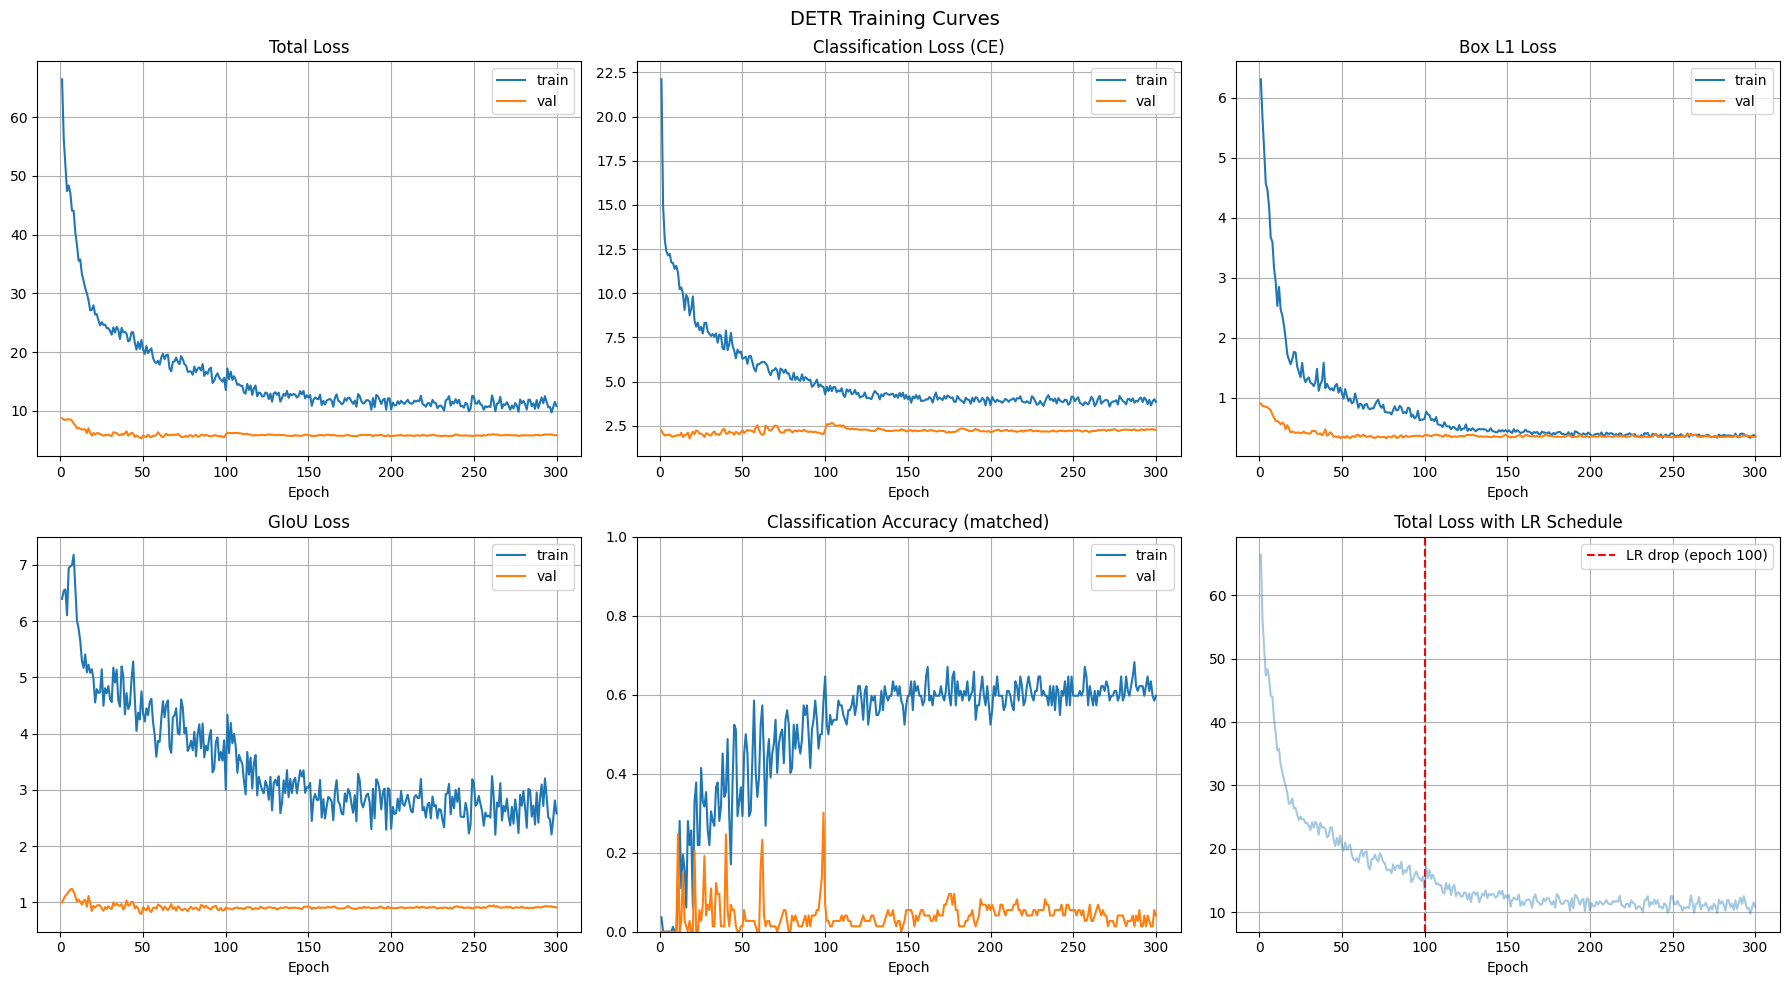

Best val loss: 5.3460
Final train acc: 59.76%
Final val acc:   4.11%


In [20]:
## Loss and accuracy plots

import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_total']) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DETR Training Curves', fontsize=14)

# Total loss
axes[0, 0].plot(epochs_range, history['train_total'], label='train')
axes[0, 0].plot(epochs_range, history['val_total'],   label='val')
axes[0, 0].set_title('Total Loss'); axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend(); axes[0, 0].grid(True)

# CE loss
axes[0, 1].plot(epochs_range, history['train_ce'], label='train')
axes[0, 1].plot(epochs_range, history['val_ce'],   label='val')
axes[0, 1].set_title('Classification Loss (CE)'); axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend(); axes[0, 1].grid(True)

# L1 loss
axes[0, 2].plot(epochs_range, history['train_l1'], label='train')
axes[0, 2].plot(epochs_range, history['val_l1'],   label='val')
axes[0, 2].set_title('Box L1 Loss'); axes[0, 2].set_xlabel('Epoch')
axes[0, 2].legend(); axes[0, 2].grid(True)

# GIoU loss
axes[1, 0].plot(epochs_range, history['train_giou'], label='train')
axes[1, 0].plot(epochs_range, history['val_giou'],   label='val')
axes[1, 0].set_title('GIoU Loss'); axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend(); axes[1, 0].grid(True)

# Accuracy
axes[1, 1].plot(epochs_range, history['train_acc'], label='train')
axes[1, 1].plot(epochs_range, history['val_acc'],   label='val')
axes[1, 1].set_title('Classification Accuracy (matched)'); axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylim(0, 1); axes[1, 1].legend(); axes[1, 1].grid(True)

# LR indicator — mark epoch 100 drop
axes[1, 2].axvline(x=100, color='red', linestyle='--', label='LR drop (epoch 100)')
axes[1, 2].plot(epochs_range, history['train_total'], alpha=0.4)
axes[1, 2].set_title('Total Loss with LR Schedule'); axes[1, 2].set_xlabel('Epoch')
axes[1, 2].legend(); axes[1, 2].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print(f'Best val loss: {best_val_loss:.4f}')
print(f'Final train acc: {history["train_acc"][-1]:.2%}')
print(f'Final val acc:   {history["val_acc"][-1]:.2%}')


Loaded best checkpoint
Train [7]: 15 pred  |  8 GT
Val   [6]:   8 pred  |  21 GT


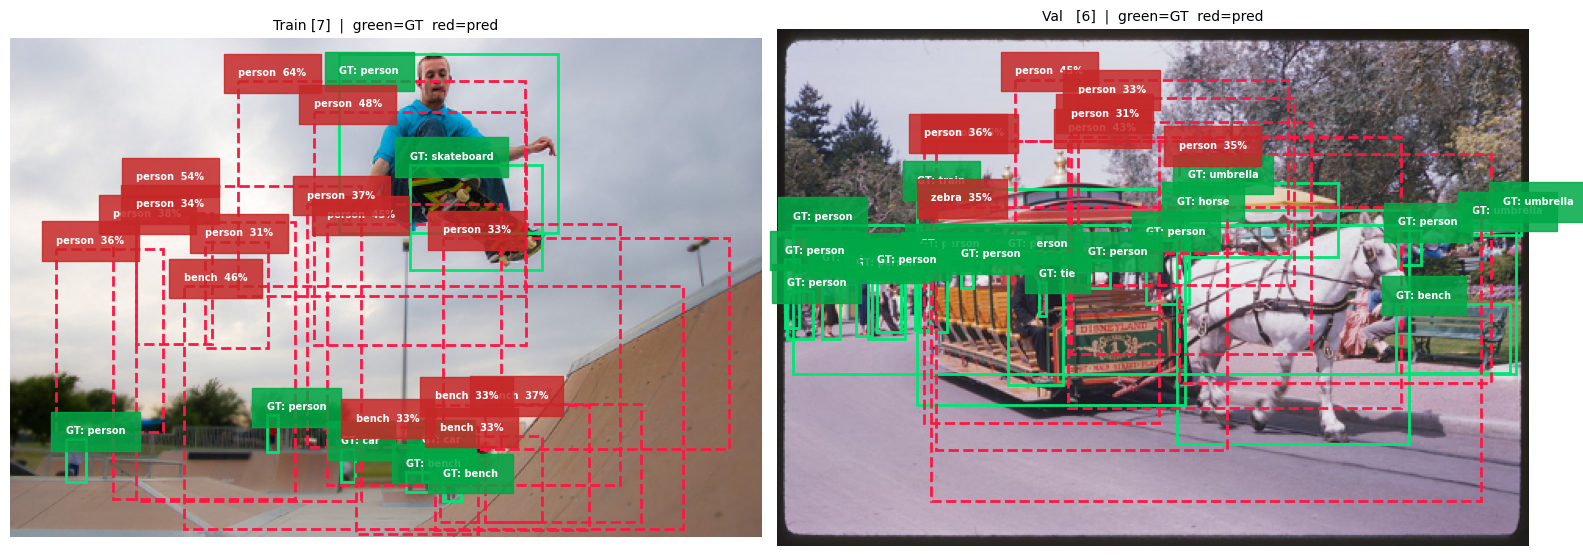

In [23]:
## Inference -- visualise predictions on a random train and val image
import random, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from dataset import collate_fn

COCO_NAMES = [
    "person","bicycle","car","motorcycle","airplane","bus","train","truck",
    "boat","traffic light","fire hydrant","stop sign","parking meter","bench",
    "bird","cat","dog","horse","sheep","cow","elephant","bear","zebra",
    "giraffe","backpack","umbrella","handbag","tie","suitcase","frisbee",
    "skis","snowboard","sports ball","kite","baseball bat","baseball glove",
    "skateboard","surfboard","tennis racket","bottle","wine glass","cup",
    "fork","knife","spoon","bowl","banana","apple","sandwich","orange",
    "broccoli","carrot","hot dog","pizza","donut","cake","chair","couch",
    "potted plant","bed","dining table","toilet","tv","laptop","mouse",
    "remote","keyboard","cell phone","microwave","oven","toaster","sink",
    "refrigerator","book","clock","vase","scissors","teddy bear","hair drier",
    "toothbrush"
]

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])

def unnormalise(tensor):
    img = tensor.cpu().clone()
    img = img * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]
    img = img.permute(1, 2, 0).numpy()
    return (img.clip(0, 1) * 255).astype(np.uint8)

def _yolo_label(ax, x1, y1, text, color, H):
    # place label inside box if box is near the top edge
    y_text = y1 - 2 if y1 > 15 else y1 + 14
    ax.text(
        x1, y_text, text,
        color="white", fontsize=7, fontweight="bold",
        va="bottom",
        bbox=dict(facecolor=color, edgecolor=color, alpha=0.85, pad=1.5, boxstyle="square")
    )

@torch.no_grad()
def run_inference(model, dataset, idx, device, threshold=0.3):
    model.eval()
    image, target = dataset[idx]
    images, masks, targets = collate_fn([(image, target)])
    images = images.to(device)
    masks  = masks.to(device)

    outputs = model(images, masks)
    logits  = outputs["pred_logits"][0]   # (100, 81)
    boxes   = outputs["pred_boxes"][0]    # (100, 4) normalised cx cy w h

    probs = logits.softmax(-1)
    scores, labels = probs[:, :-1].max(-1)   # exclude background class

    keep   = scores > threshold
    scores = scores[keep].cpu()
    labels = labels[keep].cpu()
    boxes  = boxes[keep].cpu()

    # sort by confidence descending so high-confidence labels draw on top
    order  = scores.argsort(descending=True)
    return unnormalise(image), scores[order], labels[order], boxes[order], target

def draw_predictions(ax, img, scores, labels, boxes, gt_target, title):
    H, W = img.shape[:2]
    ax.imshow(img)
    ax.set_title(title, fontsize=10, pad=6)
    ax.axis("off")

    # --- Ground truth boxes (green) with class label ---
    gt_boxes  = gt_target["boxes"]
    gt_labels = gt_target["labels"]
    for box, lbl in zip(gt_boxes, gt_labels):
        cx, cy, bw, bh = box.tolist()
        x1 = (cx - bw / 2) * W
        y1 = (cy - bh / 2) * H
        ax.add_patch(patches.Rectangle(
            (x1, y1), bw * W, bh * H,
            linewidth=2, edgecolor="#00e676", facecolor="none"
        ))
        gt_name = COCO_NAMES[lbl.item()] if lbl.item() < len(COCO_NAMES) else str(lbl.item())
        _yolo_label(ax, x1, y1, f"GT: {gt_name}", "#00a846", H)

    # --- Predicted boxes (red) with class + confidence ---
    if len(scores) == 0:
        ax.set_xlabel(f"No predictions above threshold", color="red", fontsize=9)
    for score, label, box in zip(scores, labels, boxes):
        cx, cy, bw, bh = box.tolist()
        x1 = (cx - bw / 2) * W
        y1 = (cy - bh / 2) * H
        ax.add_patch(patches.Rectangle(
            (x1, y1), bw * W, bh * H,
            linewidth=2, edgecolor="#ff1744", facecolor="none", linestyle="--"
        ))
        name = COCO_NAMES[label.item()] if label.item() < len(COCO_NAMES) else str(label.item())
        _yolo_label(ax, x1, y1, f"{name}  {score:.0%}", "#c62828", H)

# ── load best checkpoint ─────────────────────────────────────────────────────
if os.path.exists("detr_best.pth"):
    model.load_state_dict(torch.load("detr_best.pth", map_location=device, weights_only=True))
    print("Loaded best checkpoint")

# ── pick random indices ───────────────────────────────────────────────────────
train_dataset = train_loader.dataset
val_dataset   = val_loader.dataset
train_idx = random.randint(0, len(train_dataset) - 1)
val_idx   = random.randint(0, len(val_dataset)   - 1)

# ── run inference ─────────────────────────────────────────────────────────────
train_img, t_scores, t_labels, t_boxes, t_gt = run_inference(model, train_dataset, train_idx, device)
val_img,   v_scores, v_labels, v_boxes, v_gt = run_inference(model, val_dataset,   val_idx,   device)

print(f"Train [{train_idx}]: {len(t_scores)} pred  |  {len(t_gt['boxes'])} GT")
print(f"Val   [{val_idx}]:   {len(v_scores)} pred  |  {len(v_gt['boxes'])} GT")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
draw_predictions(axes[0], train_img, t_scores, t_labels, t_boxes, t_gt,
                 f"Train [{train_idx}]  |  green=GT  red=pred")
draw_predictions(axes[1], val_img,   v_scores, v_labels, v_boxes, v_gt,
                 f"Val   [{val_idx}]  |  green=GT  red=pred")
plt.tight_layout()
plt.savefig("inference_result.png", dpi=150)
plt.show()
